In [1]:
import sys
print(sys.executable)

/usr/local/anaconda3.2024/bin/python


In [2]:
from transformers import BertTokenizerFast, BertModel
import spacy
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import torch
import os

In [3]:
from data import *
from model import *
from utilsv2 import *
from analysis_topk import *

In [4]:
os.environ["TOKENIZERS_PARALLELISM"] = "true"

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Khởi tạo tokenizer và model BERT
tokenizer_bert = BertTokenizerFast.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")

# Thêm token đặc biệt nếu chưa có
special_tokens = {"additional_special_tokens": ["[E1]", "[/E1]", "[E2]", "[/E2]"]}
num_added_toks = tokenizer_bert.add_special_tokens(special_tokens)
bert.resize_token_embeddings(len(tokenizer_bert))  # Resize embedding BERT


# Tokenizer và DataLoader
spacy_nlp = spacy.load('en_core_web_sm')
spacy_nlp.tokenizer = create_custom_tokenizer(spacy_nlp, special_tokens['additional_special_tokens'])

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [6]:
data_source = "/data/ddao/TRE/data/raw_data/MATRES/data_processed/"
data_train_path = data_source + "train.csv"
data_test_path = data_source + "test.csv"

train_df = pd.read_csv(data_train_path)
test_df = pd.read_csv(data_test_path)

# Mã hóa nhãn
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
test_df['label_encoded'] = label_encoder.transform(test_df['label'])  # Ánh xạ giống tập huấn luyện

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Label Mapping: {label_mapping}")
relations = list(label_mapping.keys())


validation_size = 0.15
random_state = 42
train_df, valid_df = train_test_split(train_df, test_size=validation_size, random_state=random_state)

print("train_df:", train_df.shape)
print("valid_df:", valid_df.shape)
print("test_df:", test_df.shape)

Label Mapping: {'AFTER': 0, 'BEFORE': 1, 'EQUAL': 2, 'VAGUE': 3}
train_df: (10404, 12)
valid_df: (1836, 12)
test_df: (817, 12)


In [7]:
# --- Thống kê số lượng quan hệ trong từng tập ---
def count_relations(df, name="Dataset"):
    counts = df['label'].value_counts().sort_index()
    percents = (counts / len(df) * 100).round(2)
    stats_df = pd.DataFrame({
        'Relation': counts.index,
        f'{name} Count': counts.values,
        f'{name} %': percents.values
    })
    return stats_df

# Gộp kết quả ba tập thành một bảng duy nhất
train_stats = count_relations(train_df, "Train")
valid_stats = count_relations(valid_df, "Valid")
test_stats  = count_relations(test_df, "Test")

# Gộp tất cả vào một bảng chung (theo cột Relation)
summary_df = train_stats.merge(valid_stats, on="Relation", how="outer") \
                        .merge(test_stats, on="Relation", how="outer") \
                        .fillna(0)

# Thêm tổng cộng cho từng loại quan hệ
summary_df["Total Count"] = summary_df["Train Count"] + summary_df["Valid Count"] + summary_df["Test Count"]
summary_df["Total %"] = (summary_df["Total Count"] / summary_df["Total Count"].sum() * 100).round(2)

print("\n📊 Relation Statistics (MATRES):\n")
print(summary_df.to_string(index=False))


📊 Relation Statistics (MATRES):

Relation  Train Count  Train %  Valid Count  Valid %  Test Count  Test %  Total Count  Total %
   AFTER         3585    34.46          667    36.33         265   32.44         4517    34.59
  BEFORE         5242    50.38          942    51.31         413   50.55         6597    50.52
   EQUAL          346     3.33           59     3.21          31    3.79          436     3.34
   VAGUE         1231    11.83          168     9.15         108   13.22         1507    11.54


In [8]:
# # ✅ Loại bỏ nhãn VAGUE khỏi cả train, valid, test
# train_df = train_df[train_df['label'] != 'VAGUE'].reset_index(drop=True)
# valid_df = valid_df[valid_df['label'] != 'VAGUE'].reset_index(drop=True)
# test_df = test_df[test_df['label'] != 'VAGUE'].reset_index(drop=True)

# print("Sau khi loại bỏ VAGUE:")
# print(f"  train_df: {train_df.shape}")
# print(f"  valid_df: {valid_df.shape}")
# print(f"  test_df:  {test_df.shape}")

# # ✅ Mã hóa nhãn sau khi lọc
# label_encoder = LabelEncoder()
# train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
# valid_df['label_encoded'] = label_encoder.transform(valid_df['label'])
# test_df['label_encoded'] = label_encoder.transform(test_df['label'])

# # In mapping
# label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
# print(f"Label Mapping: {label_mapping}")

# relations = list(label_mapping.keys())
# print(f"Relations used for training: {relations}")

In [9]:
print("Create dataloader:")
batch_size = 128
window_size = 128
MAX_LENGTH = 256
shuffle=False
print("batch_size: ", batch_size)
print("window_size: ", window_size)
print("MAX_LENGTH: ", MAX_LENGTH)

Create dataloader:
batch_size:  128
window_size:  128
MAX_LENGTH:  256


In [10]:
# train_dataloader = create_dataloader(train_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_MATRES=True)
# validation_dataloader = create_dataloader(valid_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_MATRES=True)
# test_dataloader = create_dataloader(test_df, spacy_nlp, tokenizer_bert, special_tokens, batch_size, window_size, MAX_LENGTH, shuffle, is_MATRES=True)

In [11]:
train_dataloader_path =  f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/train_dataloader_ws_{window_size}.pt"
validation_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/validation_dataloader_ws_{window_size}.pt"
test_dataloader_path = f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/test_dataloader_ws_{window_size}.pt"

In [12]:
# torch.save(train_dataloader, train_dataloader_path)
# torch.save(validation_dataloader, validation_dataloader_path)
# torch.save(test_dataloader, test_dataloader_path)

In [13]:
train_dataloader = torch.load(train_dataloader_path)
validation_dataloader = torch.load(validation_dataloader_path)
test_dataloader = torch.load(test_dataloader_path)

In [21]:
# ============================================================
# Hyperparameters
# ============================================================
hidden_ffn_dim   = 512
num_heads        = 8
num_layers       = 1
dropout          = 0.3
num_classes      = len(label_encoder.classes_)

num_epochs       = 30
eval_step        = 1
LEARNING_RATE    = 1e-5

top_k            = 10


vague_label_id = label_encoder.transform(["VAGUE"])[0]
print(f"hidden_ffn_dim: {hidden_ffn_dim}")
print(f"num_layers: {num_layers}")
print(f"num_heads: {num_heads}")
print(f"top_k: {top_k}")
print(f"num_classes: {num_classes}")
print(f"vague_label_id: {vague_label_id}")

# ============================================================
# Save path
# ============================================================

save_path = (
    f"/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/"
    f"FTBERT_MATRES_MHA_{num_layers}_FFN_{hidden_ffn_dim}_TOP_{top_k}.pth"
)
print('Model will save at:', save_path)

hidden_ffn_dim: 512
num_layers: 1
num_heads: 8
top_k: 10
num_classes: 4
vague_label_id: 3
Model will save at: /data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/FTBERT_MATRES_MHA_1_FFN_512_TOP_10.pth


In [15]:
print("\nCreate model:")
model = TemporalRelationModelV2(
    bert=bert,
    tokenizer=tokenizer_bert,
    hidden_ffn_dim=hidden_ffn_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
    num_classes=num_classes,
    device=device
).to(device)

print("Device:", device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("--" * 20)


Create model:
Device: cuda
----------------------------------------


/home/prof/ddao/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [16]:
# print("\nStart Training...")
# losses = train_model(
#     model=model,
#     top_k=top_k,
#     train_dataloader=train_dataloader,
#     validation_dataloader=validation_dataloader,
#     optimizer=optimizer,
#     criterion=criterion,
#     device=device,
#     num_epochs=num_epochs,
#     save_path=save_path,
#     eval_step=eval_step,
#     max_grad_norm=1.0,      # clip grad
#     lambda_aux=1.0,         # weight cho aux loss (0 nếu không dùng)
#     is_MATRES=True,
#     vague_label_id=vague_label_id

# )

# Evaluate

In [22]:
print("Load pretrained model:")
checkpoint = torch.load(save_path)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Model saved at epoch {epoch}, loss = {loss:.4f}")

Load pretrained model:
Model saved at epoch 27, loss = 0.1848


In [ ]:
metrics_by_topk = grid_search(test_dataloader, model, 20, vague_label_id)

Evaluating: 100%|██████████| 7/7 [00:03<00:00,  2.05it/s]


Evaluation finished in 3.42s.
Filtered 108/817 (13.22%) VAGUE samples.
[TBD/MATRES] Accuracy=0.7997, F1=0.7997, P=0.7997, R=0.7997
top_K: 0 - F1: 0.7997 | Precision: 0.7997 | Recall: 0.7997



Evaluating: 100%|██████████| 7/7 [00:03<00:00,  2.08it/s]


Evaluation finished in 3.36s.
Filtered 108/817 (13.22%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8209, F1=0.8209, P=0.8209, R=0.8209
top_K: 1 - F1: 0.8209 | Precision: 0.8209 | Recall: 0.8209



Evaluating: 100%|██████████| 7/7 [00:03<00:00,  2.08it/s]


...

Evaluating: 100%|██████████| 7/7 [00:03<00:00,  2.02it/s]


Evaluation finished in 3.47s.
Filtered 108/817 (13.22%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8152, F1=0.8152, P=0.8152, R=0.8152
top_K: 18 - F1: 0.8152 | Precision: 0.8152 | Recall: 0.8152



Evaluating: 100%|██████████| 7/7 [00:03<00:00,  2.02it/s]


Evaluation finished in 3.47s.
Filtered 108/817 (13.22%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8152, F1=0.8152, P=0.8152, R=0.8152
top_K: 19 - F1: 0.8152 | Precision: 0.8152 | Recall: 0.8152



Evaluating:  71%|███████▏  | 5/7 [00:02<00:01,  1.83it/s]

In [26]:
# Tạo DataFrame
df = pd.DataFrame(metrics_by_topk, columns=["top_k", "F1", "Precision", "Recall"])
df.to_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/metrics_by_topk.csv", index=False, encoding='utf-8-sig')

In [18]:
df = pd.read_csv("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/TBD/metrics_by_topk.csv", encoding='utf-8-sig')

In [19]:
# Lấy hàng có F1 cao nhất
best_row = df.loc[df['F1'].idxmax()]

best_k = int(best_row['top_k'])
best_f1 = best_row['F1']
best_p = best_row['Precision']
best_r = best_row['Recall']

print(f"✅ Top-K tốt nhất: {best_k}")
print(f"F1 = {best_f1:.4f} | Precision = {best_p:.4f} | Recall = {best_r:.4f}")


✅ Top-K tốt nhất: 8
F1 = 0.8314 | Precision = 0.8314 | Recall = 0.8314


In [23]:
cm, f1, p, r, precisions, recalls, f1s, all_predictions, all_labels, logs = evaluate(test_dataloader,
                                                    model=model,
                                                    top_k=best_k,
                                                    device=device,
                                                    return_preds=True,
                                                    is_TBD=True,
                                                    return_topk_tokens=True,
                                                    return_logs=True,
                                                    vague_label_id=vague_label_id
                                                    )

Evaluating: 100%|██████████| 7/7 [00:03<00:00,  1.95it/s]

Evaluation finished in 3.59s.
Filtered 108/817 (13.22%) VAGUE samples.
[TBD/MATRES] Accuracy=0.8406, F1=0.8406, P=0.8406, R=0.8406


In [27]:
torch.cuda.empty_cache()

# Top-K Analysis

In [25]:
id2label = {v:k for k, v in label_mapping.items()}

In [26]:
# df_expanded = add_is_intra_batch(train_df, batch_size=64)
test_df_no_vague = test_df[test_df["label"] != "VAGUE"]
test_df_no_vague = test_df_no_vague.reset_index(drop=True)
df_expanded = add_is_intra_batch(test_df_no_vague, spacy_nlp, batch_size=64)

In [27]:
d4A = build_analysis_dataset(all_labels,
                             all_predictions,
                             logs,
                             id2label,
                             entity_pairs=df_expanded.values.tolist(),
                             vocab=spacy_nlp.vocab)  # giúp decode id → string)

In [28]:
# Write dictionary to JSON file
with open("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/data4analyze.json", "w") as json_file:
    json.dump(d4A, json_file, indent=4)

In [29]:
df_analysis = create_analysis_dataframe(d4A)

In [30]:
# df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/train_D4A.json")
df_analysis.to_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/test_D4A.json")


In [4]:
# df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/train_D4A.json")
df_analysis = pd.read_json("/data/ddao/TRE/pretrained_models/BERT_ATT_TOP_K_FFN/MATRES/test_D4A.json")

POS distribution per entity_type:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.055536  0.104196  0.018688  0.047779  0.024506  0.088329   
e2           0.060472  0.107370  0.020451  0.044252  0.023096  0.079866   
pair         0.066291  0.111601  0.019570  0.051657  0.023096  0.085155   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.189528  0.019217  0.019041  0.059062  0.126763  0.116890   
e2           0.205924  0.017807  0.020451  0.066467  0.119711  0.086742   
pair         0.173660  0.017454  0.019922  0.050247  0.128350  0.121474   

pos             SCONJ       SYM      VERB  
entity_type                                
e1           0.018688  0.000705  0.111072  
e2           0.020275  0.000705  0.126410  
pair         0.017454  0.000529  0.113

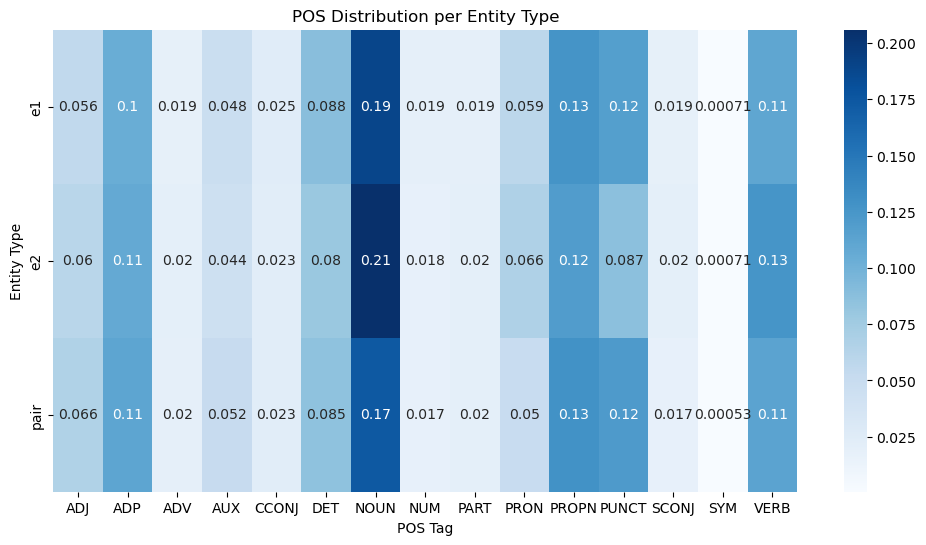

In [5]:
pos_distribution(df_analysis)

Dependency distribution per entity_type:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.034203  0.006347  0.006700  0.016044  0.024506  0.001763   
e2           0.035437  0.006523  0.004055  0.013575  0.021862  0.002645   
pair         0.037377  0.004937  0.007581  0.014810  0.025212  0.003526   

dep              amod     appos      attr       aux  ...      pobj      poss  \
entity_type                                          ...                       
e1           0.053244  0.011283  0.005818  0.041079  ...  0.087623  0.015867   
e2           0.057828  0.008639  0.006700  0.038611  ...  0.099788  0.019217   
pair         0.061354  0.011812  0.006171  0.039316  ...  0.085684  0.016396   

dep           preconj    predet      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.000000  0.000176 

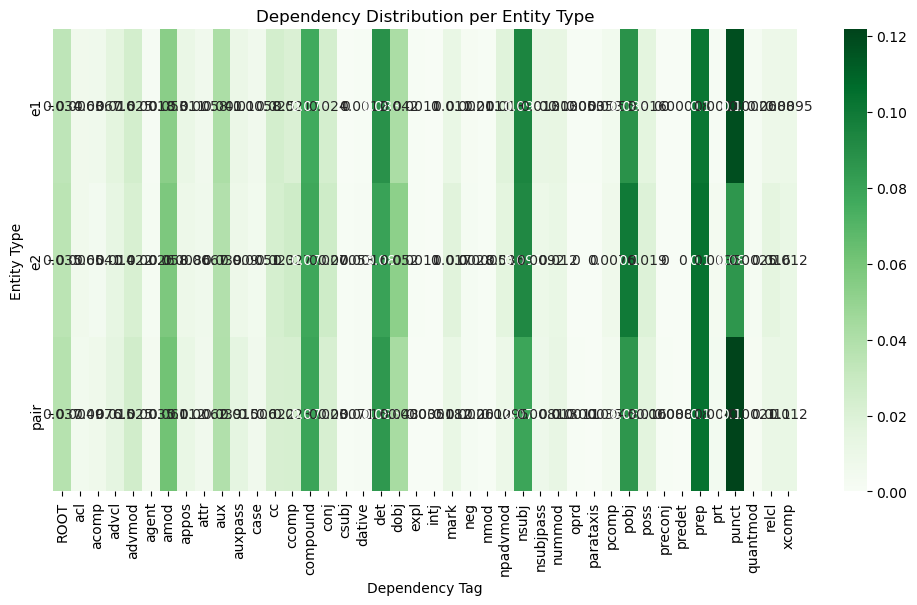

In [6]:
dep_distribution(df_analysis)

Morphology distribution per entity_type:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.169076                              0.025035   
e2           0.177539                              0.026798   
pair         0.172955                              0.025740   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.022567   
e2                                       0.022743   
pair                                     0.017807   

morph        Case=Acc|Gender=Fem|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                          
e1                                                    0.000529       
e2                                                    0.000705       
pair                                                  0.000176       

morph        Case=Acc|Gend

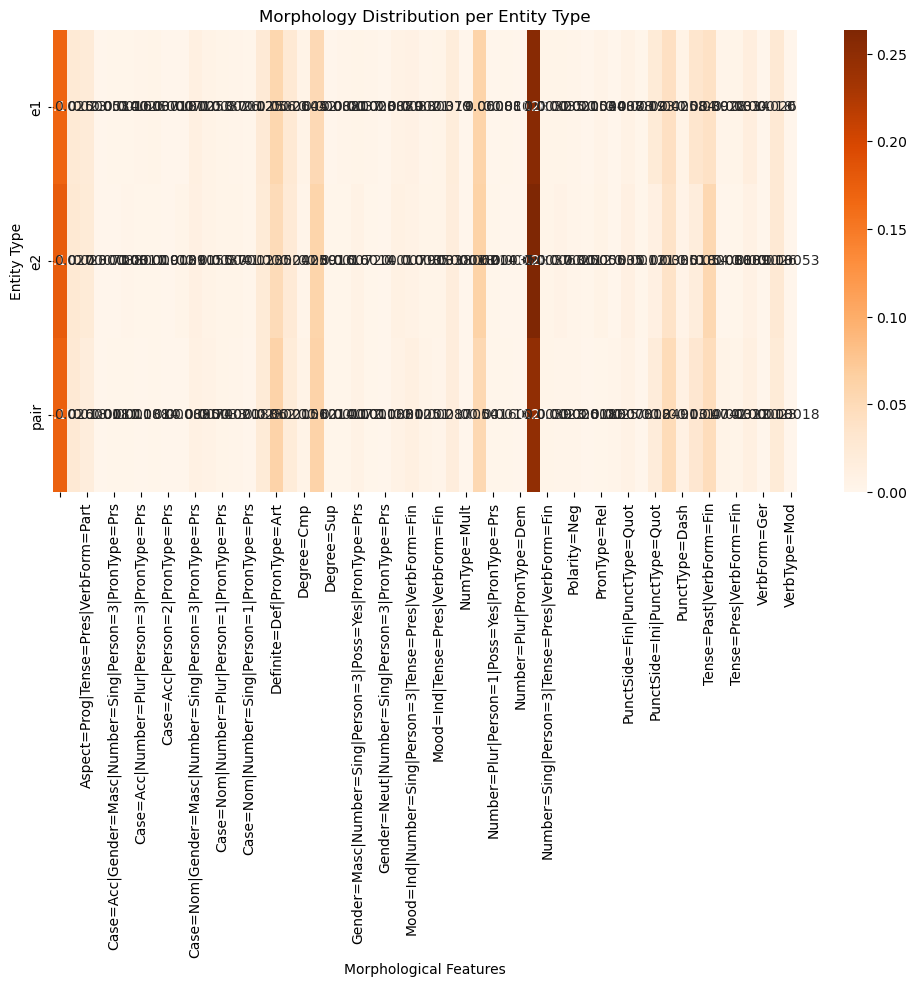

In [7]:
morph_distribution(df_analysis)

Số cặp với prediction đúng: 14304

=== Relation: BEFORE ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.058604  0.111111  0.016938  0.049119  0.029133  0.090786   
e2           0.057588  0.107724  0.021680  0.038957  0.025068  0.084011   
pair         0.068767  0.117547  0.019309  0.048780  0.027439  0.084011   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.180894  0.017615  0.022358  0.049797  0.118902  0.117547   
e2           0.221206  0.015244  0.019309  0.064024  0.116192  0.079607   
pair         0.175474  0.016938  0.022696  0.042005  0.120257  0.131436   

pos             SCONJ       SYM      VERB  
entity_type                                
e1           0.019309  0.001016  0.116870  
e2           0.019986  0.000678  0.128

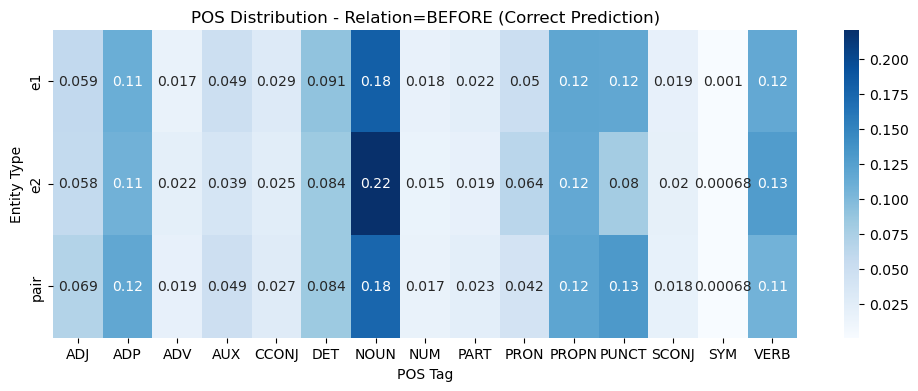

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.037263  0.005759  0.010501  0.017276  0.021341  0.002033   
e2           0.044715  0.005081  0.004743  0.014566  0.021341  0.004065   
pair         0.037263  0.002710  0.011856  0.014566  0.026423  0.004404   

dep              amod     appos      attr       aux  ...      pobj      poss  \
entity_type                                          ...                       
e1           0.053184  0.008130  0.003726  0.043360  ...  0.085705  0.016260   
e2           0.051152  0.008808  0.004743  0.034892  ...  0.118225  0.017954   
pair         0.056233  0.010840  0.001355  0.037940  ...  0.101626  0.012534   

dep           preconj    predet      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.000000  0.000339  0.108401  0.002

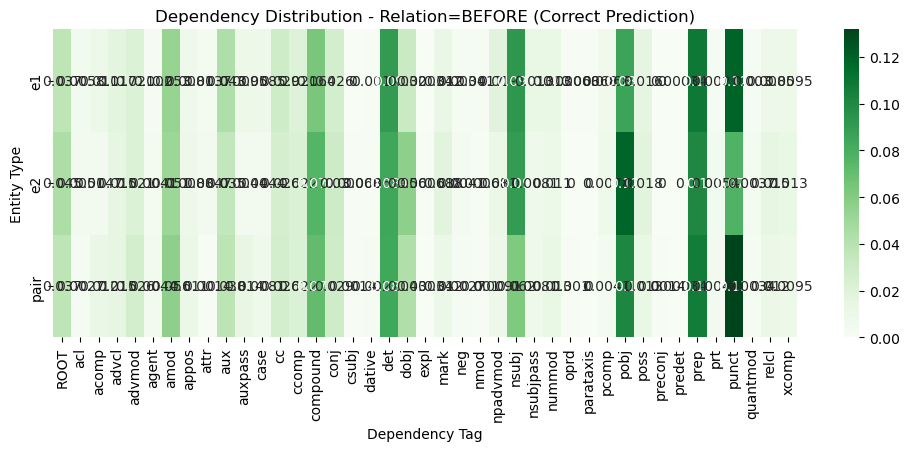

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.176829                              0.024051   
e2           0.179539                              0.024729   
pair         0.182588                              0.022019   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.026084   
e2                                       0.022019   
pair                                     0.013889   

morph        Case=Acc|Gender=Fem|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                          
e1                                                    0.000678       
e2                                                    0.001016       
pair                                                  0.000000       

morph        Case=Acc|Gender=Masc|Number=S

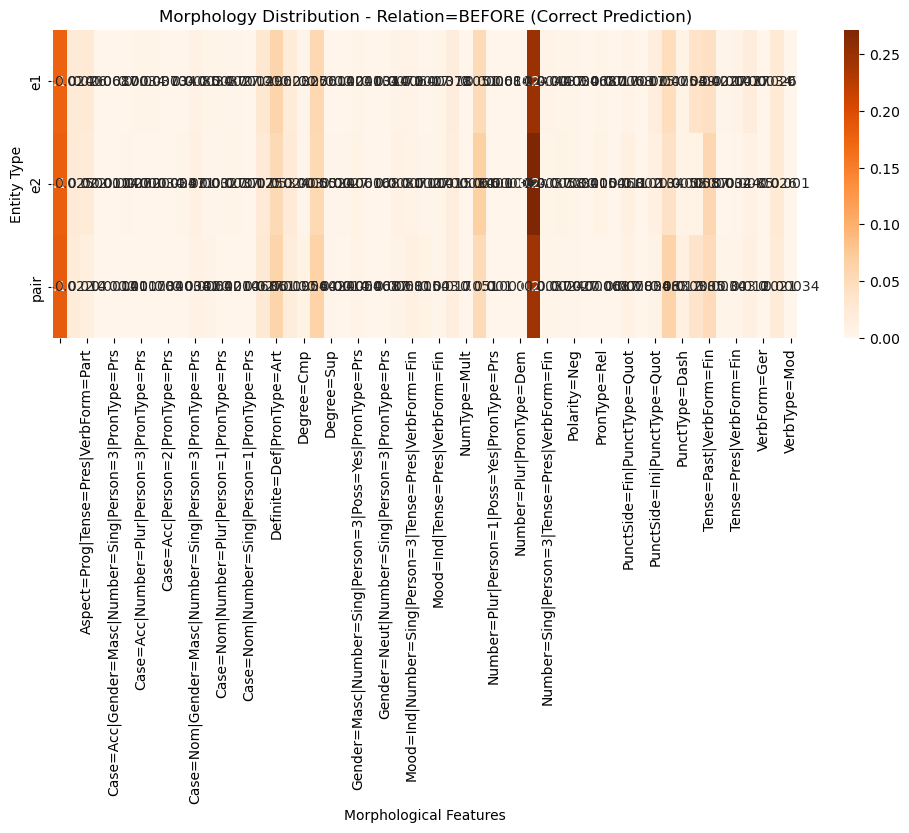


=== Relation: AFTER ===
POS distribution:
pos               ADJ       ADP       ADV       AUX     CCONJ       DET  \
entity_type                                                               
e1           0.048333  0.091667  0.020556  0.051111  0.020556  0.080556   
e2           0.061111  0.101111  0.017778  0.050556  0.017222  0.074444   
pair         0.067222  0.098333  0.018333  0.053333  0.017778  0.081667   

pos              NOUN       NUM      PART      PRON     PROPN     PUNCT  \
entity_type                                                               
e1           0.193333  0.018889  0.010556  0.074444  0.140556  0.128333   
e2           0.191667  0.016667  0.020556  0.073889  0.121111  0.100556   
pair         0.176111  0.016111  0.012222  0.063333  0.140556  0.120000   

pos             SCONJ       SYM      VERB  
entity_type                                
e1           0.018333  0.000000  0.102778  
e2           0.020556  0.001111  0.131667  
pair         0.017778  0.0000

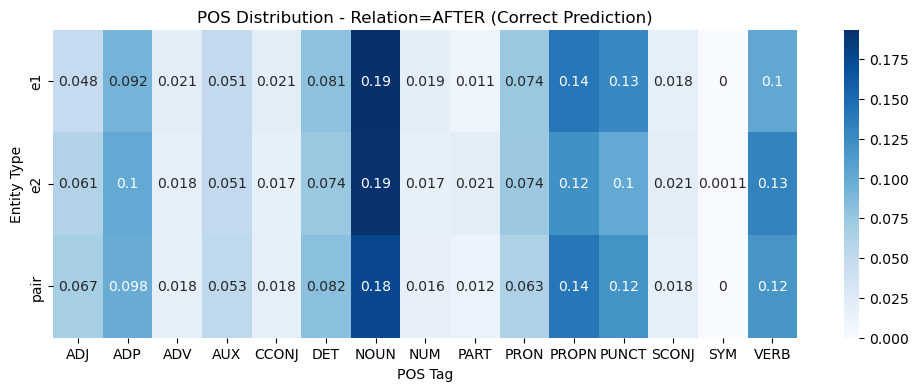

Dependency distribution:
dep              ROOT       acl     acomp     advcl    advmod     agent  \
entity_type                                                               
e1           0.028333  0.007778  0.002778  0.017778  0.028333  0.001667   
e2           0.027778  0.009444  0.004444  0.012778  0.021111  0.001111   
pair         0.032778  0.006111  0.003889  0.014444  0.020556  0.001667   

dep              amod     appos      attr       aux  ...     pcomp      pobj  \
entity_type                                          ...                       
e1           0.047778  0.014444  0.008333  0.038333  ...  0.002222  0.091667   
e2           0.061667  0.007778  0.010556  0.043889  ...  0.005556  0.079444   
pair         0.070000  0.011667  0.011667  0.036667  ...  0.002778  0.066111   

dep              poss   preconj      prep       prt     punct  quantmod  \
entity_type                                                               
e1           0.018333  0.000000  0.090000  0.001

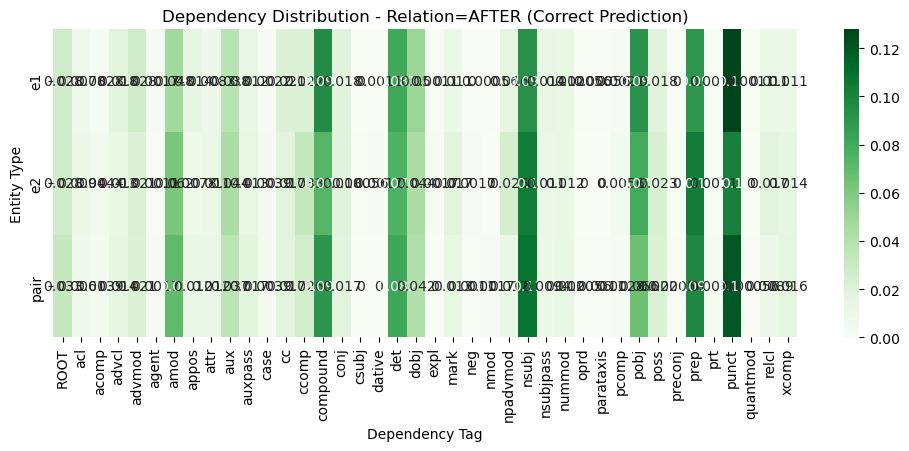

Morphology distribution:
morph                  Aspect=Perf|Tense=Past|VerbForm=Part  \
entity_type                                                   
e1           0.150000                              0.027222   
e2           0.168333                              0.031111   
pair         0.150556                              0.031111   

morph        Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                         
e1                                       0.016111   
e2                                       0.021667   
pair                                     0.018889   

morph        Case=Acc|Gender=Fem|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                          
e1                                                    0.000556       
e2                                                    0.000556       
pair                                                  0.000556       

morph        Case=Acc|Gender=Masc|Number=S

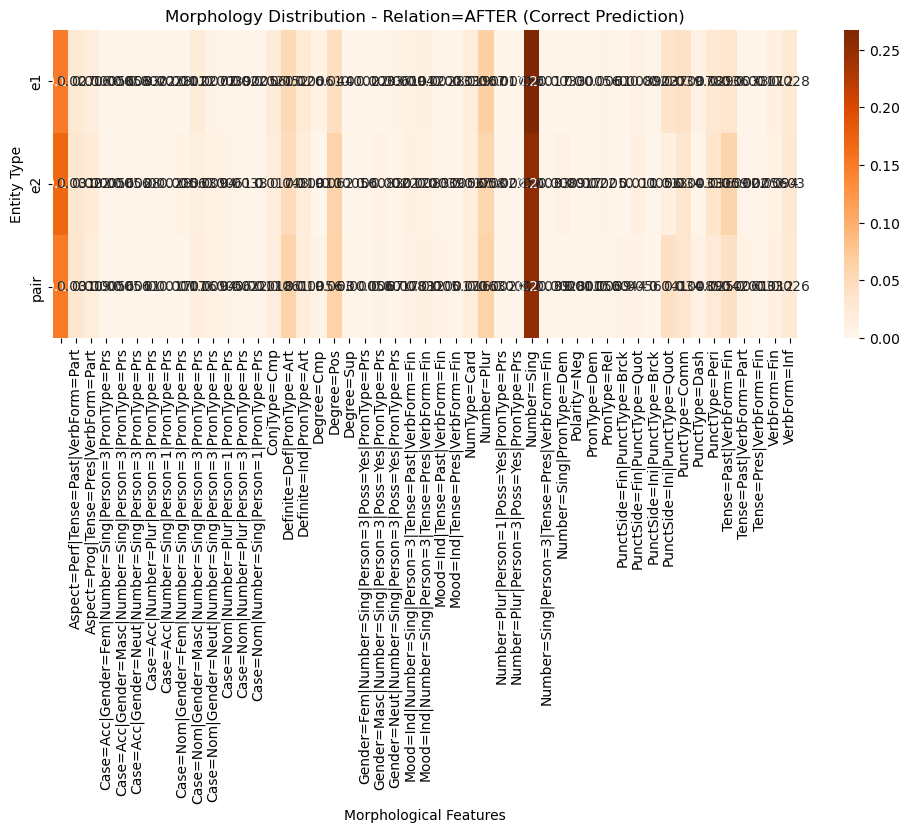


=== Relation: EQUAL ===
POS distribution:
pos            ADJ     ADP     AUX   CCONJ     DET    NOUN     NUM    PART  \
entity_type                                                                  
e1           0.000  0.0000  0.0625  0.0000  0.0000  0.0625  0.0625  0.1250   
e2           0.125  0.1250  0.0000  0.0625  0.0625  0.0625  0.0000  0.0625   
pair         0.000  0.0625  0.1250  0.0000  0.0000  0.0000  0.0000  0.1250   

pos           PRON   PROPN   PUNCT    VERB  
entity_type                                 
e1           0.125  0.2500  0.2500  0.0625  
e2           0.125  0.1875  0.1250  0.0625  
pair         0.000  0.2500  0.3125  0.1250  


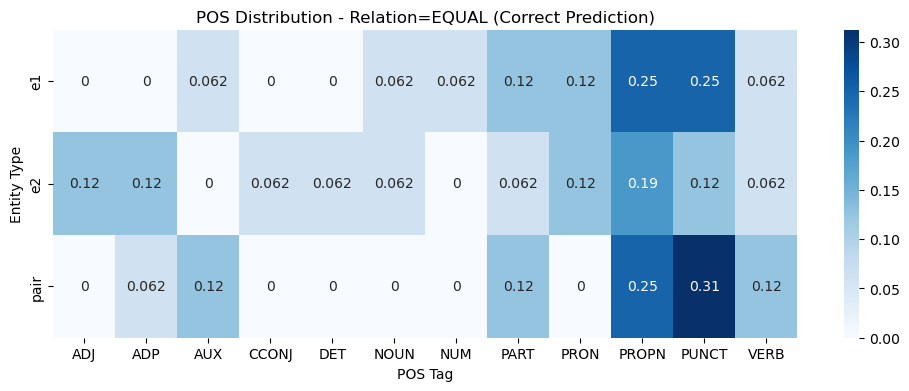

Dependency distribution:
dep           advcl   amod   appos     aux      cc  compound    conj     det  \
entity_type                                                                    
e1           0.0625  0.000  0.1250  0.0625  0.0000    0.1250  0.0625  0.0000   
e2           0.0000  0.125  0.0625  0.0625  0.0625    0.0625  0.0000  0.0625   
pair         0.0000  0.000  0.0625  0.1875  0.0000    0.1250  0.0000  0.0000   

dep            dobj     neg   nsubj   pcomp    pobj    prep   punct   xcomp  
entity_type                                                                  
e1           0.0000  0.0625  0.1250  0.0000  0.0625  0.0000  0.2500  0.0625  
e2           0.0625  0.0000  0.1875  0.0625  0.0000  0.1250  0.1250  0.0000  
pair         0.0000  0.0625  0.0000  0.0625  0.0625  0.0625  0.3125  0.0625  


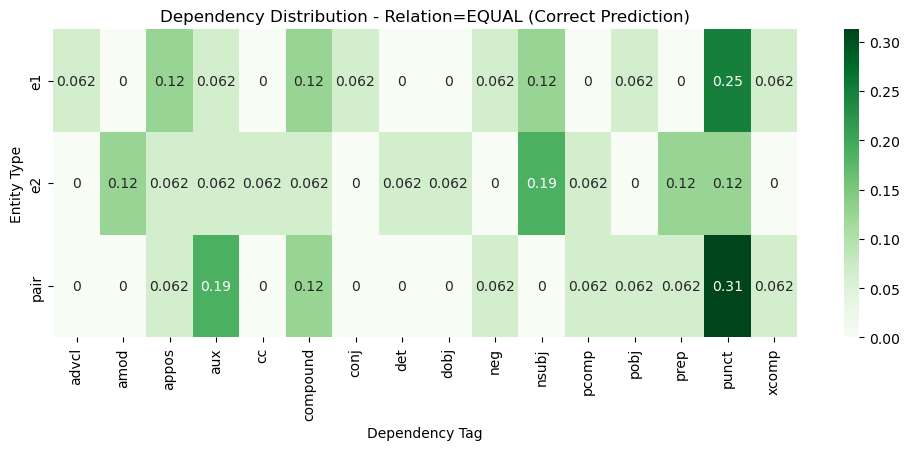

Morphology distribution:
morph                Aspect=Prog|Tense=Pres|VerbForm=Part  \
entity_type                                                 
e1           0.0625                                0.0000   
e2           0.1875                                0.0625   
pair         0.1250                                0.0000   

morph        Case=Nom|Gender=Neut|Number=Sing|Person=3|PronType=Prs  \
entity_type                                                           
e1                                                      0.0625        
e2                                                      0.0625        
pair                                                    0.0000        

morph        Case=Nom|Number=Plur|Person=3|PronType=Prs  \
entity_type                                               
e1                                               0.0000   
e2                                               0.0625   
pair                                             0.0000   

morph        Case

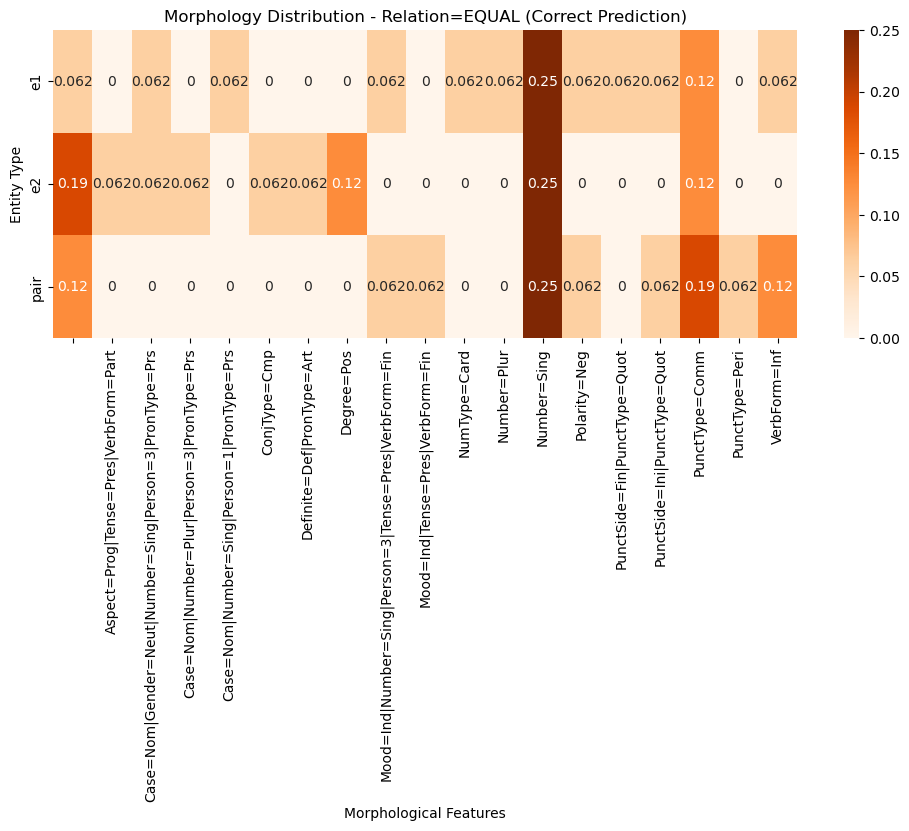

In [8]:
analyze_pos_dep_morph_by_relation(df_analysis)